<a href="https://colab.research.google.com/github/fernandodeeke/epidemy/blob/main/sir_basic_disc_est.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estimated beta:  0.9761
Estimated gamma: 0.5559
Estimated $R_0$: 1.7560

--- Fit quality (in-sample, I counts) ---
SSE  = 5657.745
MSE  = 188.591
RMSE = 13.733
MAE  = 11.782
R^2  = 0.8955
AIC  = 161.187
BIC  = 163.990


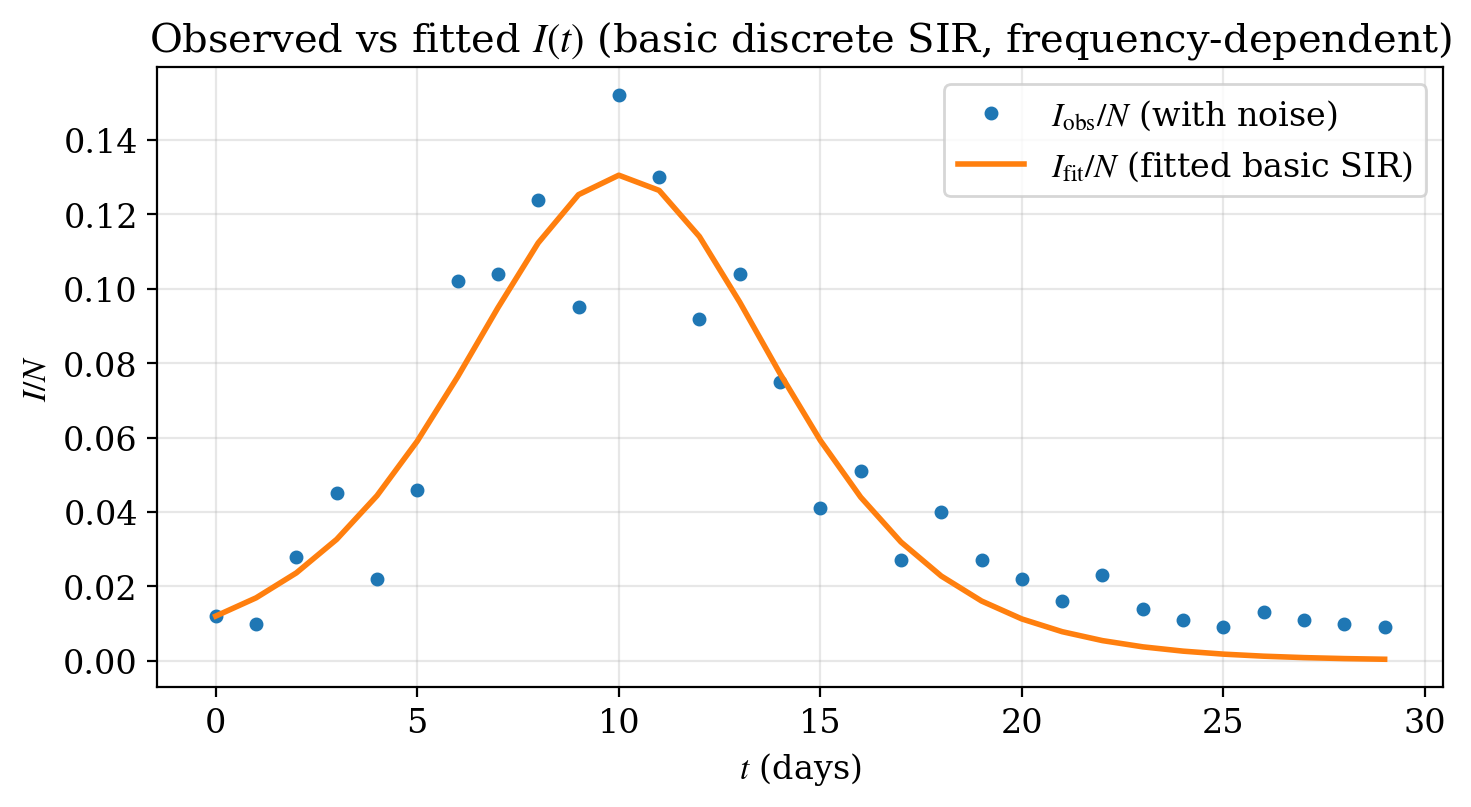

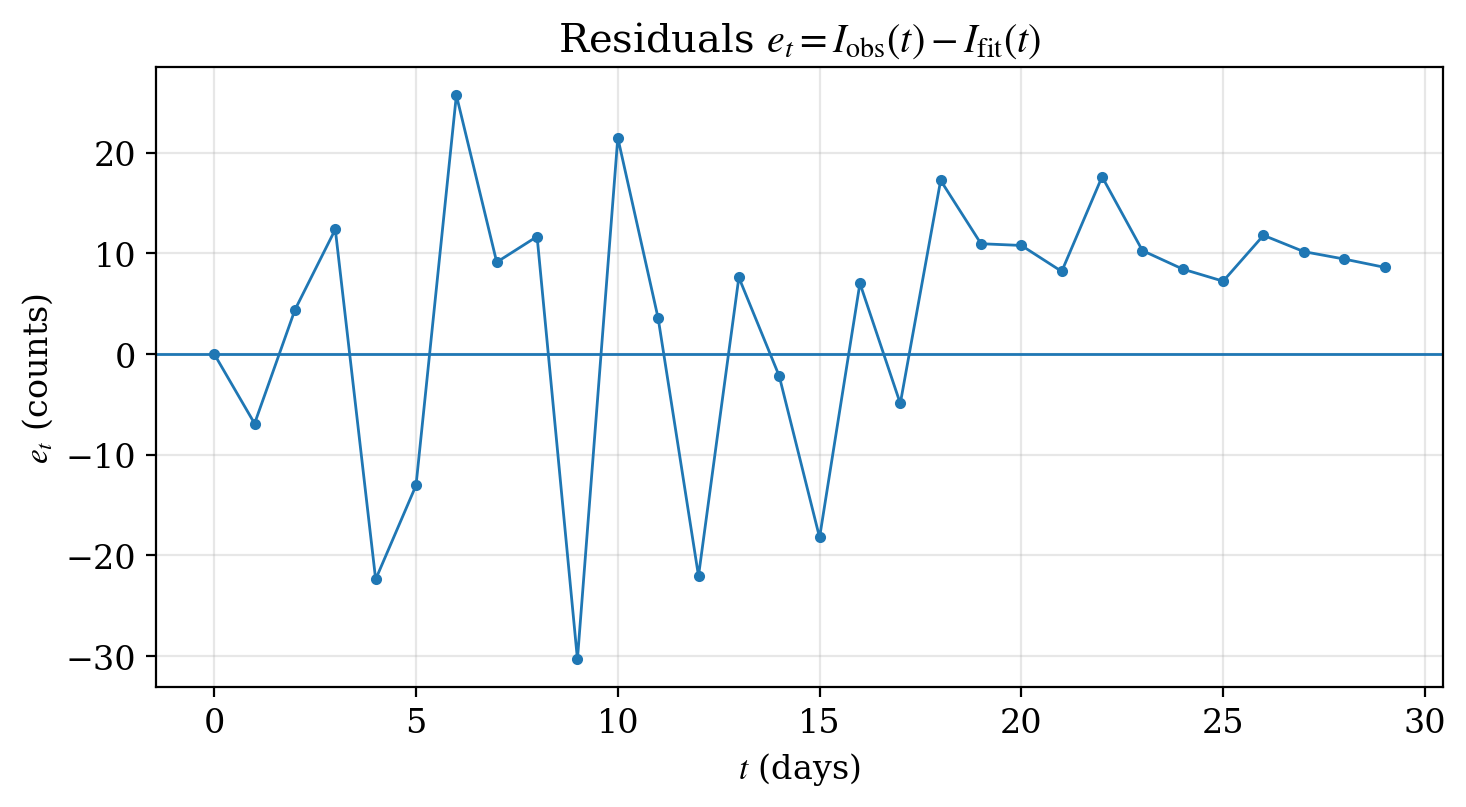

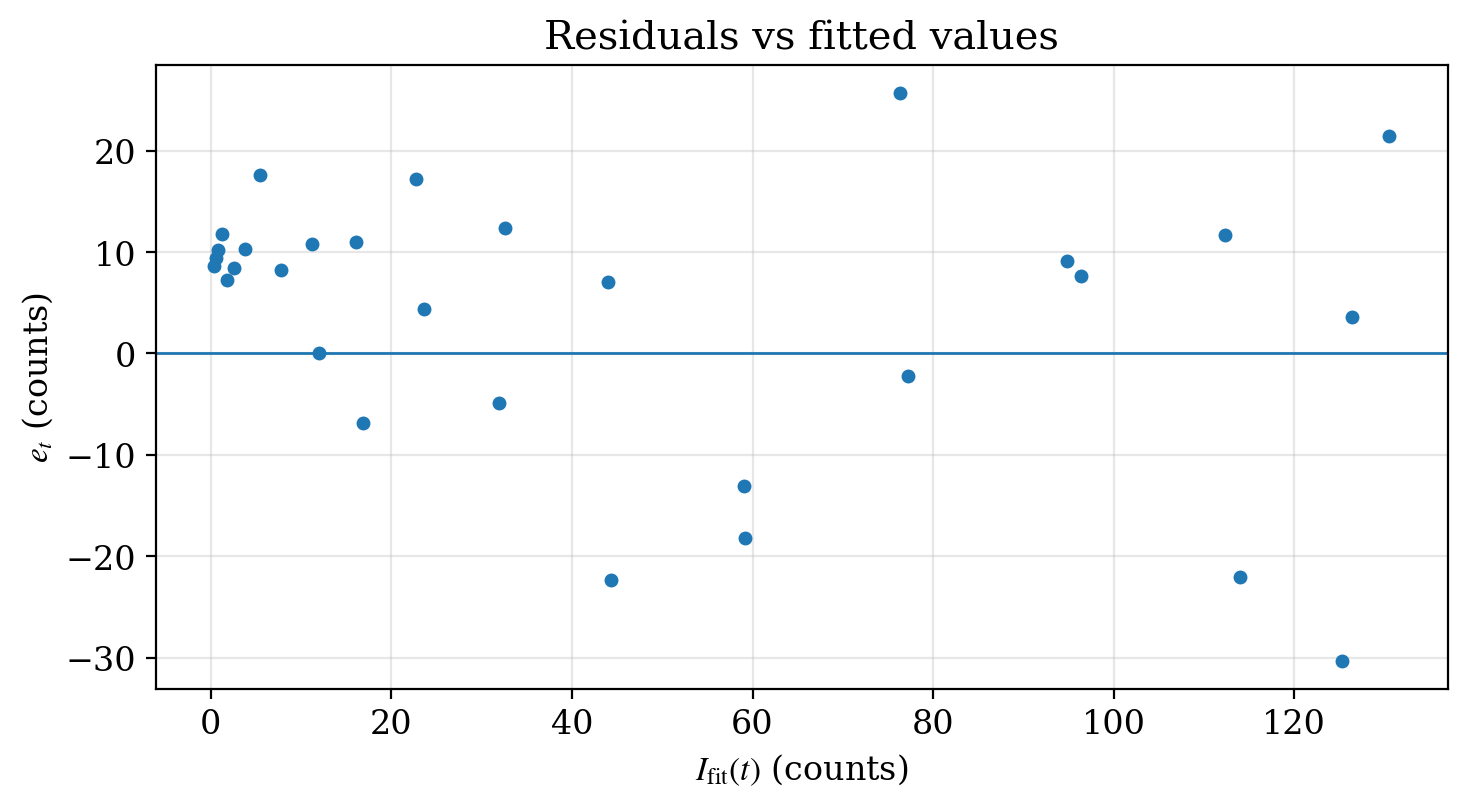

In [4]:
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 12,
})

# ============================================================
# PARAMETER FITTING IN THE BASIC DISCRETE SIR MODEL (EULER)
# Frequency-dependent transmission (incidence ~ S*I/N)
# ============================================================


def sir_basic(params, S0, I0, R0, N, days):
    beta, gamma = params

    S = np.zeros(days, dtype=float)
    I = np.zeros(days, dtype=float)
    R = np.zeros(days, dtype=float)

    S[0], I[0], R[0] = S0, I0, R0

    for t in range(days - 1):
        S[t + 1] = S[t] - beta * S[t] * I[t] / N
        I[t + 1] = I[t] + (beta * S[t] * I[t] / N - gamma * I[t])
        R[t + 1] = R[t] + gamma * I[t]
        if I[t + 1] < 0:
            I[t + 1] = 0.0

    return I


def sir_basic_full(params, S0, I0, R0, N, days):
    beta, gamma = params

    S = np.zeros(days, dtype=float)
    I = np.zeros(days, dtype=float)
    R = np.zeros(days, dtype=float)

    S[0], I[0], R[0] = S0, I0, R0

    for t in range(days - 1):
        S[t + 1] = S[t] - beta * S[t] * I[t] / N
        I[t + 1] = I[t] + (beta * S[t] * I[t] / N - gamma * I[t])
        R[t + 1] = R[t] + gamma * I[t]
        if I[t + 1] < 0:
            I[t + 1] = 0.0

    return S, I, R


def objective(params, I_obs, S0, I0, R0, N):
    I_pred = sir_basic(params, S0, I0, R0, N, len(I_obs))
    return np.sum((I_pred - I_obs) ** 2)


# -----------------------------
# Data (baseline + noise)
# -----------------------------
I_b = np.array([
    10, 15, 23, 35, 52, 75, 98, 115, 125, 128, 120, 105,
    90, 78, 66, 55, 46, 38, 32, 27, 23, 20, 17, 15,
    13, 11, 10, 9, 8, 7
])

N = 1000
rng = np.random.default_rng(42)

noise_frac = 0.30
noise_sd = np.maximum(5, noise_frac * I_b)

I_obs = np.rint(I_b + rng.normal(0.0, noise_sd)).astype(int)
I_obs = np.clip(I_obs, 0, N)

S0, I0, R0 = N - I_obs[0], I_obs[0], 0
t = np.arange(len(I_obs))


# -------------------------------------------------------------------
# OPTIMIZATION: least squares fit
# -------------------------------------------------------------------
initial_guess = [0.5, 0.1]

result = minimize(
    objective, initial_guess,
    args=(I_obs, S0, I0, R0, N),
    bounds=[(0, 2), (0, 1)]
)

beta_est, gamma_est = result.x
R0_est = beta_est / gamma_est if gamma_est > 0 else np.inf

print(f"Estimated beta:  {beta_est:.4f}")
print(f"Estimated gamma: {gamma_est:.4f}")
print(f"Estimated $R_0$: {R0_est:.4f}")


# -------------------------------------------------------------------
# FIT EVALUATION (in-sample)
# -------------------------------------------------------------------
I_est = sir_basic([beta_est, gamma_est], S0, I0, R0, N, len(I_obs))
resid = I_obs.astype(float) - I_est

n = len(I_obs)
k = 2  # number of fitted parameters: beta, gamma

SSE = float(np.sum(resid**2))
MSE = SSE / n
RMSE = float(np.sqrt(MSE))
MAE = float(np.mean(np.abs(resid)))

# R^2 against a mean-only baseline (note: can be negative if model is worse than mean)
SST = float(np.sum((I_obs - np.mean(I_obs))**2))
R2 = 1.0 - SSE / SST if SST > 0 else np.nan

# Information criteria using a Gaussian error model (up to an additive constant)
# With sigma^2 = SSE/n, the log-likelihood (ignoring constants) is:
#   ll = -(n/2) * [1 + ln(2π) + ln(SSE/n)]
# We can use the standard AIC/BIC formulas.
if SSE > 0:
    AIC = n * np.log(SSE / n) + 2 * k
    BIC = n * np.log(SSE / n) + k * np.log(n)
else:
    AIC, BIC = -np.inf, -np.inf

print("\n--- Fit quality (in-sample, I counts) ---")
print(f"SSE  = {SSE:.3f}")
print(f"MSE  = {MSE:.3f}")
print(f"RMSE = {RMSE:.3f}")
print(f"MAE  = {MAE:.3f}")
print(f"R^2  = {R2:.4f}")
print(f"AIC  = {AIC:.3f}")
print(f"BIC  = {BIC:.3f}")



# -------------------------------------------------------------------
# 1) PLOT: observed I vs fitted I
# -------------------------------------------------------------------
plt.figure(figsize=(7.5, 4.2), dpi=200)
plt.plot(t, I_obs / N, "o", label=r"$I_{\mathrm{obs}}/N$ (with noise)", markersize=4)
plt.plot(t, I_est / N, "-", label=r"$I_{\mathrm{fit}}/N$ (fitted basic SIR)", linewidth=2)
plt.title(r"Observed vs fitted $I(t)$ (basic discrete SIR, frequency-dependent)")
plt.xlabel(r"$t$ (days)")
plt.ylabel(r"$I/N$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("sir_basic_fit_I.png", dpi=600, bbox_inches="tight")
plt.savefig("sir_basic_fit_I.pdf", bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------
# Residual diagnostics plots
# -------------------------------------------------------------------
plt.figure(figsize=(7.5, 4.2), dpi=200)
plt.axhline(0.0, linewidth=1)
plt.plot(t, resid, "o-", markersize=3, linewidth=1)
plt.title(r"Residuals $e_t = I_{\mathrm{obs}}(t) - I_{\mathrm{fit}}(t)$")
plt.xlabel(r"$t$ (days)")
plt.ylabel(r"$e_t$ (counts)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("sir_basic_residuals_timeseries.png", dpi=600, bbox_inches="tight")
plt.savefig("sir_basic_residuals_timeseries.pdf", bbox_inches="tight")
plt.show()

plt.figure(figsize=(7.5, 4.2), dpi=200)
plt.plot(I_est, resid, "o", markersize=4)
plt.axhline(0.0, linewidth=1)
plt.title(r"Residuals vs fitted values")
plt.xlabel(r"$I_{\mathrm{fit}}(t)$ (counts)")
plt.ylabel(r"$e_t$ (counts)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("sir_basic_residuals_vs_fit.png", dpi=600, bbox_inches="tight")
plt.savefig("sir_basic_residuals_vs_fit.pdf", bbox_inches="tight")
plt.show()



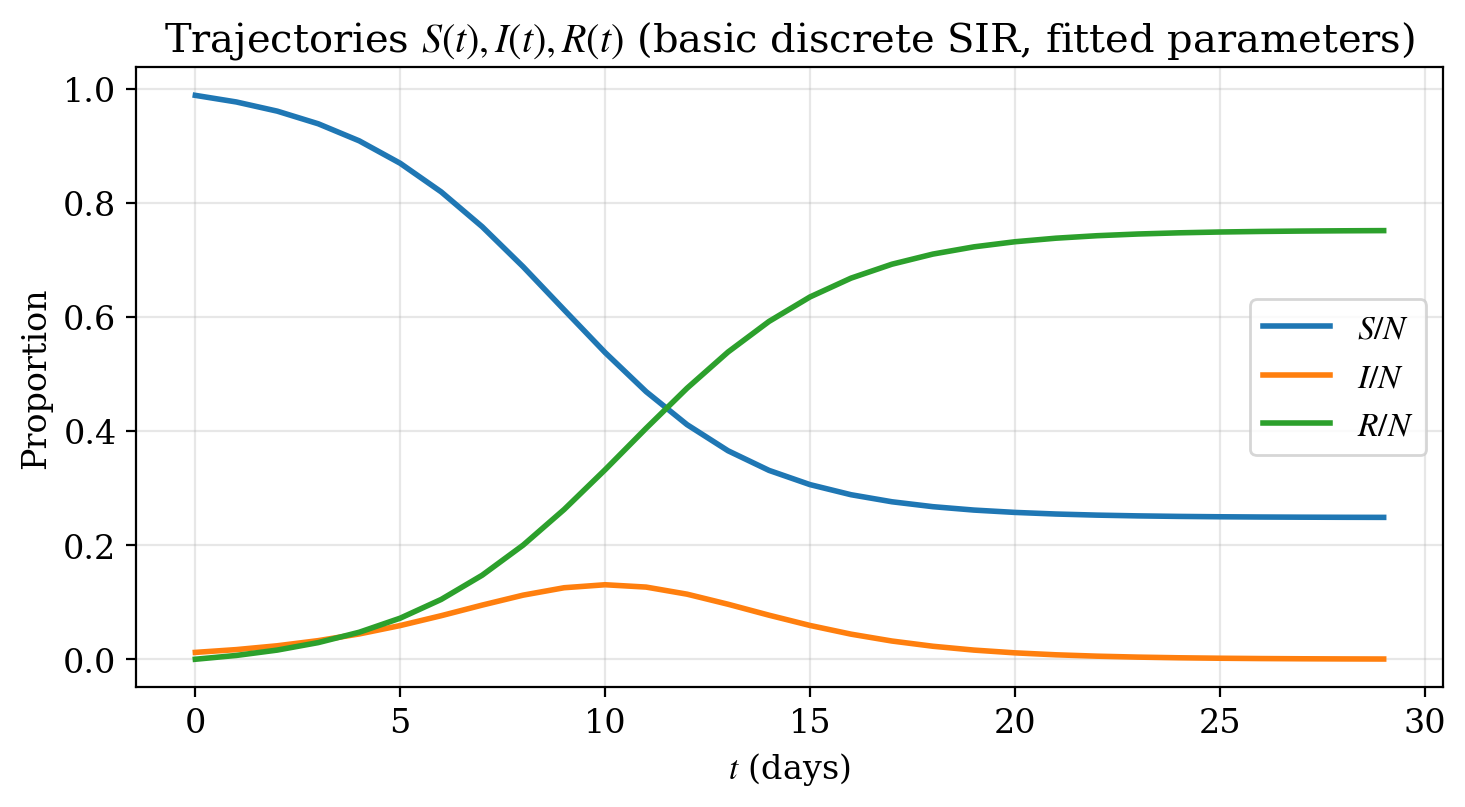

In [3]:
# -------------------------------------------------------------------
# 2) PLOT: S, I, R trajectories with estimated parameters
# -------------------------------------------------------------------
S_fit, I_fit, R_fit = sir_basic_full([beta_est, gamma_est], S0, I0, R0, N, len(I_obs))

plt.figure(figsize=(7.5, 4.2), dpi=200)
plt.plot(t, S_fit / N, label=r"$S/N$", linewidth=2)
plt.plot(t, I_fit / N, label=r"$I/N$", linewidth=2)
plt.plot(t, R_fit / N, label=r"$R/N$", linewidth=2)
plt.title(r"Trajectories $S(t), I(t), R(t)$ (basic discrete SIR, fitted parameters)")
plt.xlabel(r"$t$ (days)")
plt.ylabel(r"Proportion")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("sir_basic_fit_SIR.png", dpi=600, bbox_inches="tight")
plt.savefig("sir_basic_fit_SIR.pdf", bbox_inches="tight")
plt.show()